###  Import necessary lib

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import pydicom
import numpy as np
import os
import glob
from tqdm import tqdm
import warnings

In [10]:
train = pd.read_csv('C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\train.csv')

In [11]:
print("Total Cases: ",len(train))

Total Cases:  1975


In [12]:
train.columns

Index(['study_id', 'spinal_canal_stenosis_l1_l2',
       'spinal_canal_stenosis_l2_l3', 'spinal_canal_stenosis_l3_l4',
       'spinal_canal_stenosis_l4_l5', 'spinal_canal_stenosis_l5_s1',
       'left_neural_foraminal_narrowing_l1_l2',
       'left_neural_foraminal_narrowing_l2_l3',
       'left_neural_foraminal_narrowing_l3_l4',
       'left_neural_foraminal_narrowing_l4_l5',
       'left_neural_foraminal_narrowing_l5_s1',
       'right_neural_foraminal_narrowing_l1_l2',
       'right_neural_foraminal_narrowing_l2_l3',
       'right_neural_foraminal_narrowing_l3_l4',
       'right_neural_foraminal_narrowing_l4_l5',
       'right_neural_foraminal_narrowing_l5_s1',
       'left_subarticular_stenosis_l1_l2', 'left_subarticular_stenosis_l2_l3',
       'left_subarticular_stenosis_l3_l4', 'left_subarticular_stenosis_l4_l5',
       'left_subarticular_stenosis_l5_s1', 'right_subarticular_stenosis_l1_l2',
       'right_subarticular_stenosis_l2_l3',
       'right_subarticular_stenosis_l3_l4',
 

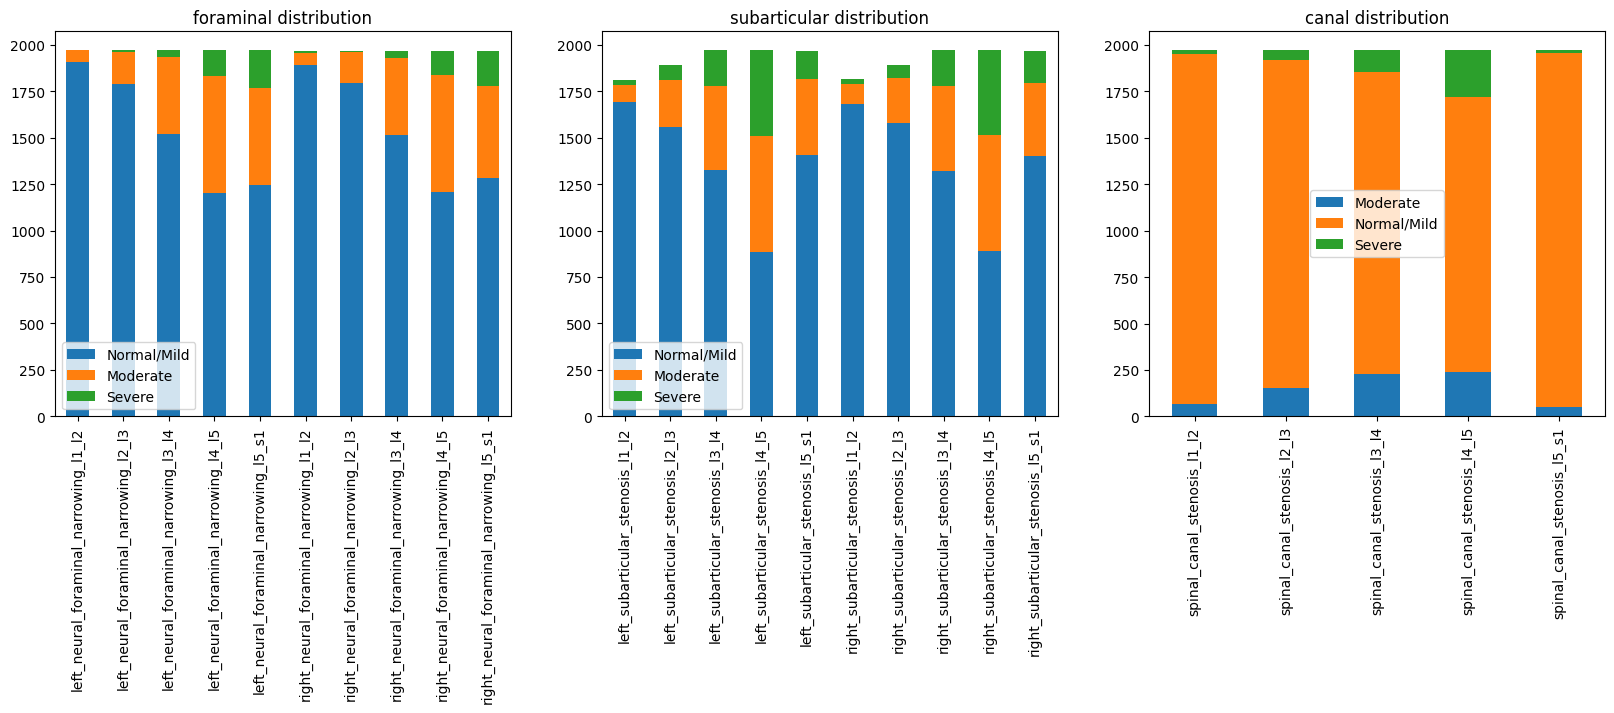

In [17]:
figure , axis =plt.subplots(1,3,figsize=(20,5))

for idx,d in enumerate(['foraminal','subarticular','canal']):
    diagnosis =list(filter(lambda x:x.find(d) > -1, train.columns))
    dff = train[diagnosis]
    with warnings.catch_warnings():
        warnings.simplefilter(action='ignore', category=FutureWarning)
        value_counts= dff.apply(pd.value_counts).fillna(0).T
    value_counts.plot(kind='bar',stacked=True,ax=axis[idx])
    axis[idx].set_title(f'{d} distribution')

In [15]:
part_1 = os.listdir('C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\train_images')
print_1 = list(filter(lambda x:x.find(' .DS') == -1 ,part_1))

In [18]:
df_meta_f=pd.read_csv('C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\train_series_descriptions.csv')

In [19]:
df_meta_f.head()

,study_id,series_id,series_description
0,4003253,702807833,Sagittal T2/STIR
1,4003253,1054713880,Sagittal T1
2,4003253,2448190387,Axial T2
3,4646740,3201256954,Axial T2
4,4646740,3486248476,Sagittal T1


In [20]:
p1 = [(x,f'C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\train_images\\{x}') for x in part_1]
meta_obj = { p[0]:{'folder_path':p[1],
                   'SerisInstanceUIDs':[]}
for p in p1}
    

In [21]:
for m in meta_obj:
    meta_obj[m]['SeriesInstanceUIDs'] = list(
        filter(lambda x: x.find('.DS') == -1, 
               os.listdir(meta_obj[m]['folder_path'])
              )
    )

In [22]:
for k in tqdm(meta_obj):
    for s in meta_obj[k]['SeriesInstanceUIDs']:
        if 'SeriesDescriptions' not in meta_obj[k]:
            meta_obj[k]['SeriesDescriptions'] = []
        try:
            meta_obj[k]['SeriesDescriptions'].append(
                df_meta_f[(df_meta_f['study_id'] == int(k)) & 
                (df_meta_f['series_id'] == int(s))]['series_description'].iloc[0])
        except:
            print("Failed on", s, k)

100%|██████████| 239/239 [00:00<00:00, 719.67it/s]


In [23]:
meta_obj[list(meta_obj.keys())[1]]

{'folder_path': 'C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\train_images\\1002894806',
 'SerisInstanceUIDs': [],
 'SeriesInstanceUIDs': ['1252873726', '801316590', '866293114'],
 'SeriesDescriptions': ['Axial T2', 'Sagittal T2/STIR', 'Sagittal T1']}

In [24]:
patient = train.iloc[1]

In [26]:
patient_id = str(patient['study_id'])
if patient_id in meta_obj:
    ptobj = meta_obj[patient_id]
else:
    print(f"Study ID {patient_id} not found in train images directory")
    ptobj = None

Study ID 4646740 not found in train images directory


In [28]:
print(ptobj)

None


In [31]:
df_coor = pd.read_csv('rsna-2024-lumbar-spine-degenerative-classification/RSNA 2024 Lumbar Spine/train_label_coordinates.csv')

In [32]:
df_coor.head()

,study_id,series_id,instance_number,condition,level,x,y
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602
